In [1]:
import os
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import json
import glob
import matplotlib.pyplot as plt

from Tools import load_schema
from Tools import LisParse

from IPython.display import JSON

import re

from Tools.Metainfo.metainfo import Quantity, MissingQuantity

from Tools.SchemaMappings.schema_mappings import map_bam_to_schema

# Fill the schema with reference data

In order to ilustrate the use of the data schema, we will fill it with reference data. For this we 
1. Load the schema
2. fill with data

In [2]:
schema = load_schema()

In [3]:
JSON(schema)

<IPython.core.display.JSON object>

As reference data we have a bunch of LIS files with metadata as well as raw data (time - elongation tables)

In [4]:
lis_file_list = glob.glob('../data/BAM_Dataset/*.LIS')

In [5]:
lis_file = '../data/BAM_Dataset/BCR425-280-1.LIS'

In [6]:
jsoned_lis = {}

In [7]:
for lis_file in lis_file_list:
    data = LisParse.Data(lis_file)
    jsoned_lis[lis_file] = data.parse_lis()

# Map reference data into the schema

In [8]:
schema_compliant_data = {}

In [9]:
for lis_file, jsoned_data in jsoned_lis.items():
    schema_compliant_data[lis_file] = map_bam_to_schema(schema, jsoned_data)

In [10]:
JSON(schema_compliant_data)

<IPython.core.display.JSON object>

we save the reference data into json files, for easy access

In [11]:
for lis_file, compliant_jsoned_data in schema_compliant_data.items():
    compliant_bam_file_basename = 'compliant_'+os.path.basename(lis_file).replace('LIS','json')
    compliant_bam_file = os.path.join(os.path.dirname(lis_file), compliant_bam_file_basename)
    with open(compliant_bam_file, 'w') as f:
        json.dump(compliant_jsoned_data, f)

# Some plots 

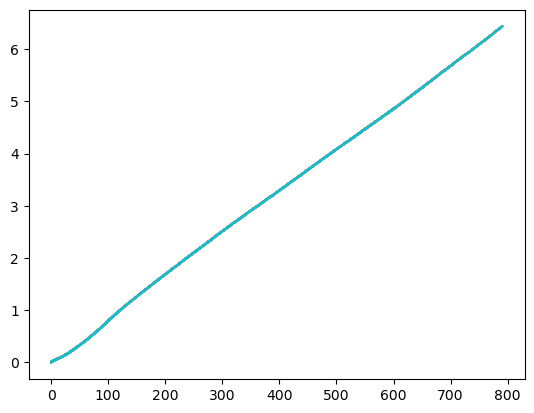

In [12]:
fig, ax = plt.subplots()
for lis_file, jsoned_data in schema_compliant_data.items():
    y = jsoned_data['Primary data']['Test results']['raw_elongations']['Value']
    x = jsoned_data['Primary data']['Test results']['raw_times']['Value']
    y_unit = jsoned_data['Primary data']['Test results']['raw_elongations']['Unit']
    x_unit = jsoned_data['Primary data']['Test results']['raw_times']['Unit']
    ax.plot(x,y)